# Tutorial per simulare eventi di GGSL in ammassi di galassie

Questo tutorial mostra come utilizzare le funzioni contenute nella libreria ```pyLensLib``` per simulare eventi di lensing forte prodotti da galassie d'ammasso su altre galassie retrostanti.

La procedura da implementare consiste nei seguenti passaggi:

* utiliziamo le ricostruzioni di alcuni ammassi di galassie osservati come deflettori;
* per un dato redshift delle sorgenti, individuiamo le linee critiche secondarie di questi ammassi (collegate quindi alle galassie d'ammasso);
* calcoliamo le caustiche corrispondenti;
* posizioniamo delle sorgenti (che possono essere descritte da modelli di Sersic o essere vere galassie) in prossimita' delle caustiche secondarie e applichiamo l'effetto di lensing del deflettore
* sommiamo le immagini delle sorgenti distorte alle osservazioni HST per ottenere delle simulazioni realistiche

## Esempio

Iniziamo con l'importare alcuni moduli che saranno necessari per la successiva analisi:

In [1]:
from pyLensLib.deflector import deflector
from pyLensLib.observation import observation
from pyLensLib.sersic import sersic
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pyfits
from astropy.cosmology import FlatLambdaCDM
from astropy.coordinates import SkyCoord, funcs
from astropy.wcs import WCS
from astropy import units as u
from astropy.nddata import Cutout2D
import aplpy
co = FlatLambdaCDM(Om0=0.3,H0=70.0)

Andiamo a definire la posizione dei dati che utilizzeremo sulla macchina dove saranno realizzate le simulazioni. Per questo esercizio, useremo le immagini RGB di alcuni ammassi e le corrispondenti mappe degli angoli di deflessione. Specifichiamo anche le coordinate dei centri degli ammassi (RA e DEC) e i redshift.

In [2]:
# immagini RGB

cluster_rgb = ['/Users/massimo/stiva/MACS1206/CLASH/macs1206_RGB.fits',
               '/Users/massimo/stiva/RGBs/macs0416_ff_30mas_RGB.fits',
               '/Users/massimo/stiva/RGBs/2248_ff_RGB.fits',
               '/Users/massimo/stiva/RGBs/A370_RGB.fits',
               '/Users/massimo/stiva/RGBs/abell2744_RGB.fits',
               '/Users/massimo/stiva/RGBs/macs0717_RGB.fits',
               '/Users/massimo/stiva/RGBs/1149_60mas_ff.fits_RGB.fits',
               '/Users/massimo/stiva/RGBs/macs0329_RGB.fits',
               '/Users/massimo/stiva/RGBs/macs1931_RGB.fits',
               '/Users/massimo/stiva/RGBs/macs2129_RGB.fits',
               '/Users/massimo/stiva/RGBs/rxj2129_RGB.fits']

# coordinate dei centri (RA DEC) 
coords = ['181.550620 -8.800936','64.038142 -24.067472','342.183210 -44.530878',
          '39.971369 -1.582382','3.586259 -30.400174','109.398200 37.745778','177.398730 22.398529',
          '52.423328 -2.196151','292.956746 -26.575727','322.358800 -7.691050','322.416470 0.089230']

# cluster nickname (necessari per costruire i nomi dei file da leggere)
cluster = ['M1206pl','M0416','S1063',
           'A370','A2744','M0717','M1149',
           'M0329','M1931','M2129','R2129']

# posizione delle mappe degli angoli di deflessione
path_to_angles = ['/Users/massimo/stiva/pietro_models/',
                  '/Users/massimo/stiva/pietro_models/shifted/',
                  '/Users/massimo/stiva/pietro_models/',
                  '/Users/massimo/stiva/FF/lens_models/from_params/',
                  '/Users/massimo/stiva/FF/lens_models/from_params/',
                  '/Users/massimo/stiva/FF/lens_models/from_params/',
                  '/Users/massimo/stiva/FF/lens_models/from_params/',
                  '/Users/massimo/stiva/gabriel_models/best_fit/',
                  '/Users/massimo/stiva/gabriel_models/best_fit/',
                  '/Users/massimo/stiva/gabriel_models/best_fit/',
                  '/Users/massimo/stiva/gabriel_models/best_fit/']

# redshift delle lenti
zl = [0.439,0.396,0.348,0.375,0.308,0.545,0.543,0.45,0.352,0.587,0.234]

Costruiamo il deflettore per il primo ammasso nella lista. Si tratta di MACSJ1206. 

In [4]:
def create_deflector(nick,filex,filey,zl,zs,co,zsnorm=1.0):

    angx_hd=pyfits.open(filex)
    angy_hd=pyfits.open(filey)
    
    try:
        if (angx_hd[0].header['CDELT1'] == 1.0):
            pixels=-3600.0*angx_hd[0].header['CD1_1']
        else:
            pixels=-3600.0*angx_hd[0].header['CDELT1']
    except:
        pixels=-3600.0*angx_hd[0].header['CD1_1'] 
        
    a1=angx_hd[0].data
    a2=angy_hd[0].data
    
    npix=a1.shape[0]
    fov_ray = pixels*(npix-1)
    
    # per costruire i deflettore, oltre agli angoli di deflessione, dobbiamo anche 
    # specificare i redshift di lente e sorgente (si tratta dei redshift usati per 
    # calcolare gli angoli di deflessiobe ridotti letti in a1 e a2)
    # Questi redshift vanno inseriti in un dizionario e passati al deflettore
    kwargs_def={'zl': zl, 'zs': zsnorm}
    df=deflector(co,angx=a1,angy=a2,**kwargs_def)
    # dobbiamo anche indicare le coordinate dei punti nei quali sono stati calcolati 
    # a1 e a2:
    theta=np.linspace(-fov_ray/2.,fov_ray/2.,npix)
    df.setGrid(theta=theta,compute_potential=False)
    # infine definiamo il redshift delle sorgenti che dovremo distorcere
    df.change_redshift(zs)
    return df,fov_ray

# Usiamo le informazioni specificate sopra per costruire i nomi dei files da leggere:
filex = path_to_angles[0]+cluster[0]+'_angx.fits'
filey = path_to_angles[0]+cluster[0]+'_angy.fits'
# costruiamo il deflettore
zs=3
df,fov_ray=create_deflector(nick=cluster_rgb[0],filex=filex,filey=filey,co=co,zl=zl[0],zs=zs)

A scopo puramente illustrativo, costruiamo una funzione che mostra l'immagine RGB dell'ammasso (ritagliata in modo da corrispondere esattamente all'area sottesa dalle mappe di deflessione) e le linee critiche della lente.

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
        Incon

INFO: Red: [aplpy.rgb]
INFO: vmin =  0.000e+00 (auto) [aplpy.rgb]
INFO: vmax =  1.610e+02 (auto) [aplpy.rgb]
INFO: Green: [aplpy.rgb]
INFO: vmin =  0.000e+00 (auto) [aplpy.rgb]
INFO: vmax =  1.570e+02 (auto) [aplpy.rgb]
INFO: Blue: [aplpy.rgb]
INFO: vmin =  0.000e+00 (auto) [aplpy.rgb]
INFO: vmax =  1.140e+02 (auto) [aplpy.rgb]


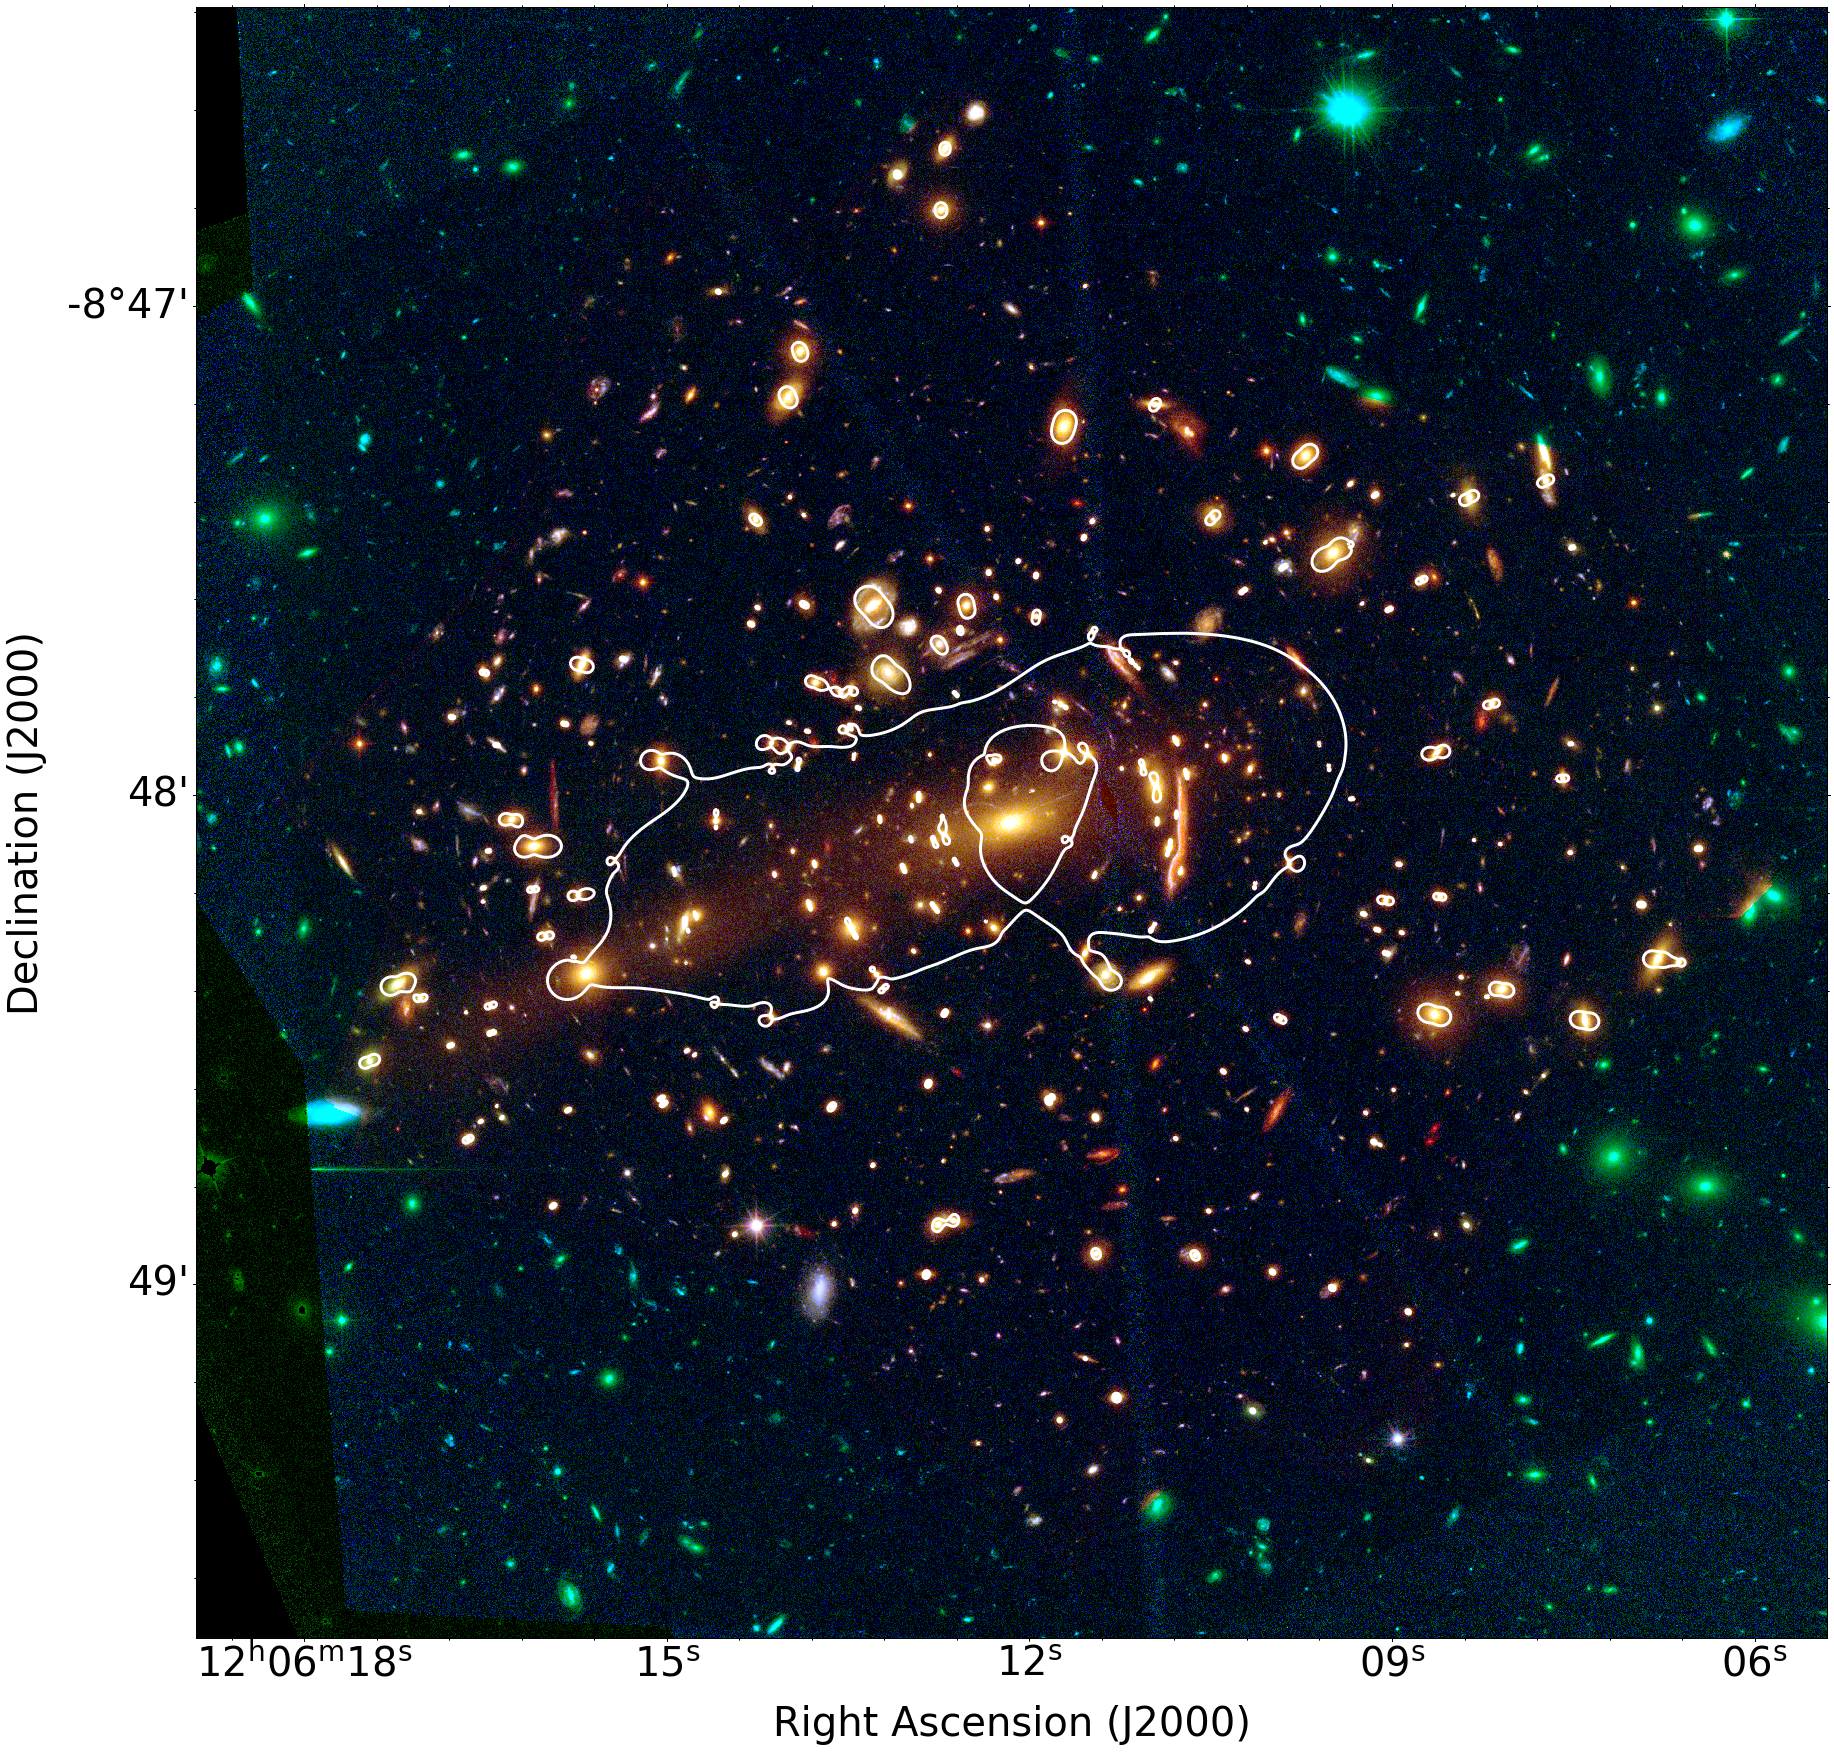

In [11]:
def cutout(filename,position,fov):
    hdul=pyfits.open(filename)
    image=hdul[0].data
    w = WCS(filename)
    size = u.Quantity((fov, fov), u.arcsec)
    position = SkyCoord(coords, frame='fk5',unit="deg")  
    cutout_ = Cutout2D(image, position, size, wcs=w)
    w_up=cutout_.wcs
    header = w_up.to_header()
    return cutout_,header


def create_rgb_image(rgbimage,coords,fig,df,fov=200.0):

    hdul=pyfits.open(rgbimage)
    w = WCS(rgbimage)

    rimage=hdul[1].data
    gimage=hdul[2].data
    bimage=hdul[3].data

    size = u.Quantity((fov, fov), u.arcsec)
    position = SkyCoord(coords, frame='fk5',unit="deg")

    cutout_r = Cutout2D(rimage, position, size, wcs=w)
    w_up=cutout_r.wcs
    cutout_g = Cutout2D(gimage, position, size, wcs=w)
    cutout_b = Cutout2D(bimage, position, size, wcs=w)
    
    image_cube = np.zeros((3, cutout_r.data.shape[0], cutout_r.data.shape[1]), dtype=np.float32)
    image_cube[0,:,:]=cutout_r.data
    image_cube[1,:,:]=cutout_g.data
    image_cube[2,:,:]=cutout_b.data

    header = w_up.to_header()
    hdu_r = pyfits.PrimaryHDU(cutout_r.data,header=header)
    hdulist = pyfits.HDUList([hdu_r])
    hdulist.writeto('tmp_r.fits',overwrite=True)

    pyfits.writeto('tmp.fits', image_cube, header, overwrite=True)
    aplpy.make_rgb_image('tmp.fits','cropped.png')
    
    f = aplpy.FITSFigure('tmp_r.fits',figure=fig,figsize=(30,30))
    t=f.show_rgb('cropped.png')
    
    # la funzione tancl() del deflettore df calcola le linee critiche tangenziali e le salva in una lista (qui cl)
    cl=df.tancl()
    l=[]
    for i in range(len(cl)):
        x,y=df.getCritPoints(cl[i]) # x,y offsets
        # trasformiamo gli offest in RA e DEC 
        xw=-x/3600.0/np.cos(position.dec.value*np.pi/180.0)+position.ra.value
        yw=y/3600.0+position.dec.value
        l.append(np.column_stack((xw, yw)).T)
        
    f.show_lines(l,color='white',linestyle='-',linewidth=3)
    
    # la funzione radcl() del deflettore calcola invece le linee critiche radiali
    rl=df.radcl()
    l=[]
    for i in range(len(rl)):
        x,y=df.getCritPoints(rl[i]) # x,y offsets
        xw=-x/3600.0/np.cos(position.dec.value*np.pi/180.0)+position.ra.value
        yw=y/3600.0+position.dec.value
        l.append(np.column_stack((xw, yw)).T)
        
    f.show_lines(l,color='white',linestyle='-',linewidth=3)
    
        
    
    f.axis_labels.set_font(size=40)
    f.tick_labels.set_font(size=40)
    f.tick_labels.set_xformat('hh:mm:ss')
    f.tick_labels.set_yformat('dd:mm')
    #f.add_label(0.1, 0.92, panel_label, relative=True,size=40,color='white',weight='bold')
    f.axis_labels.set_xtext('Right Ascension (J2000)')
    f.axis_labels.set_ytext('Declination (J2000)')
    return f,cl,rl

%matplotlib inline
fig = plt.figure(figsize=(30, 30))

# con questa chiamata otteniamo in un colpo solo: l'immagine RGB dell'ammasso e delle sue linee critiche; 
# le linee critiche tangenziali e radiali
f,cl,rl=create_rgb_image(cluster_rgb[0],coords[0],fig=fig,df=df)

fig.savefig('m1206_hst.png')

La funzione ```tancl()``` restituisce le linee critiche in ordine di grandezza (dalla piu' grande alla piu' piccola). 

Calcoliamo le caustiche e troviamo le posizioni della i-esima linea critica e della sua caustica: 

In [38]:
# Mappiamo le linee critiche nelle caustiche:
caut=df.getCaustics(cl)

# consideriamo la i-esima linea critica (idlc):
idcl=4
x,y=df.getCritPoints(cl[idcl])
print (x.mean(),y.mean())
xc,yc=df.getCausticPoints(caut[idcl])
print (xc.mean(),yc.mean())

39.44499053183811 32.932739228288014
19.233868071142922 8.032809946026033


Expected e-/s from source:   5.9704


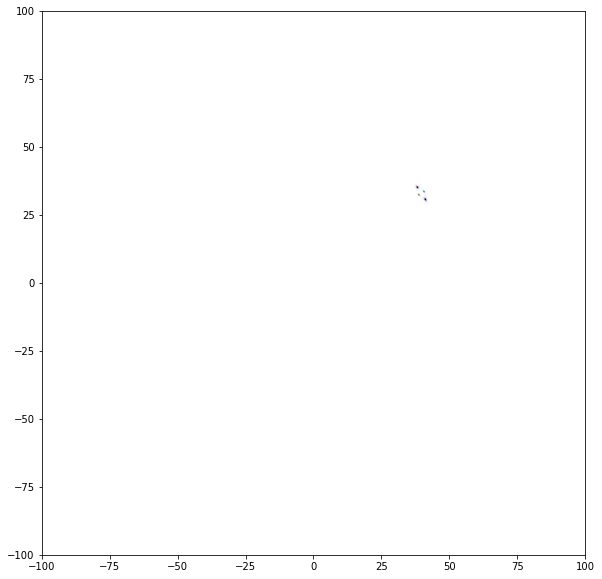

In [17]:
# Mettiamo una sorgente al centro della caustica scelta. La sorgente ha magnitudine 24. 
# Assumendo che lo zero-point del telescopio sia 25.94, calcoliamo i conteggi totali che ci aspettiamo sul CCD.
# Per questo usiamo la classe observation: specifichiamo campo di vista, numero di pixel, zeropoint, tempo di esposizione (il bkg e' irrilevante)
mag_source=24.
ob = observation(size=fov_ray, Npix=df.nray, zp=25.94, texp=565*4, bkg=22.0)
# convertiamo la magnitudine in conteggi usando la funzione mag2counts
fl_gal=ob.mag2counts(mag_source)
print (('Expected e-/s from source: %8.4f') % (fl_gal))
# specifichiamo le caratteristiche della sorgente. Assumiamo abbia un profilo di brillanza di Sersic e che sia
# posizionata proprio al centro della caustica (xc.mean(),yc.mean()).
# NB: il redshift deve essere lo stesso del deflettore!
kwargs_source_light={
    'n': 1.0, # sersic index
    're': 0.2, # effective radius
    'q': 1.0, # axis ratio
    'pa': np.pi/4., # position angle
    'ys1': xc.mean(), # position x (on the source plane)
    'ys2': yc.mean(), # position y (on the lens plane)
    'flux': fl_gal, # flux of the source (in counts/s)
    'zs': 3.0
}
se=sersic(size=fov_ray, Npix=df.nray,gl=df,**kwargs_source_light)
fig,ax=plt.subplots(1,1,figsize=(10,10))
ax.imshow(se.image,origin='lower',extent=[-100,100,-100,100],vmax=se.image.max()*0.5,cmap='cubehelix_r')


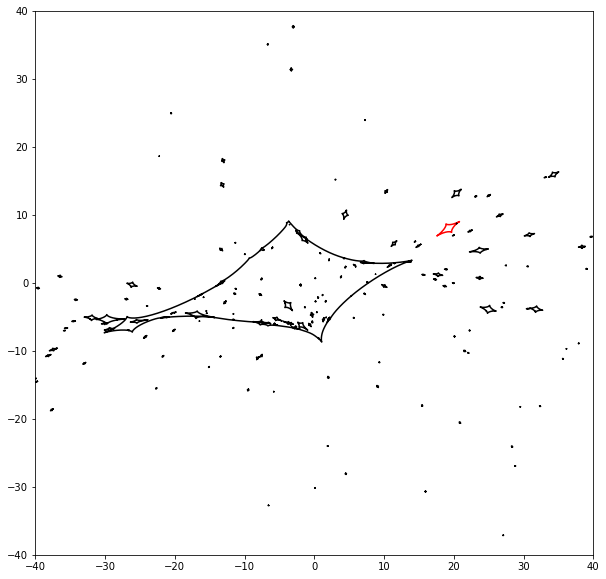

In [18]:
fig,ax=plt.subplots(1,1,figsize=(10,10))
for i in range(len(caut)):
    x,y=df.getCausticPoints(caut[i])
    if i==idcl:
        ax.plot(x,y,'-',color='red')
    else:
        ax.plot(x,y,'-',color='black')
ax.set_xlim([-40,40])
ax.set_ylim([-40,40])
fig.savefig('m1206_caustics.png')

# Assegniamo una SED alla sorgente

Sebbene ci siano diversi software per la sintesi di popolazioni stellari che possono produrre SED utili a descrivere le nostre sorgenti, ci affidiamo ad un software per la misura di redshift fotometrici chiamato [BPZ](https://www.stsci.edu/~dcoe/BPZ/). Uno dei metodi utilizzati per la misura dei redshift fotometrici consiste nel fittare le magnitudini osservate in diverse bande con dei template. BPZ lavora proprio in questo modo ed e' quindi provvisto di una libreria di templates che possiamo utilizzare per descrivere le galassie che usiamo come sorgenti. 

Vediamo quali templates sono disponibili nella libreria ```eB11.list```:

In [19]:
homedir='/Users/massimo/CODES/bpz-1.99.3/SED/'
sed_list = homedir+'eB11.list'
import pandas as pd
seds_df = pd.read_csv(sed_list,header=None,delim_whitespace=True)
seds_df.columns=['sed']
seds_df

,sed
0,Ell7_A_0.sed
1,Ell6_A_0.sed
2,Ell5_A_0.sed
3,Ell4_A_0.sed
4,ES0_B10.sed
5,Sbc_B10.sed
6,Scd_B10.sed
7,SB1_B10.sed
8,SB2_B10.sed
9,SB3_B10.sed


Proviamo ora a visualizzare le varie SEDs:

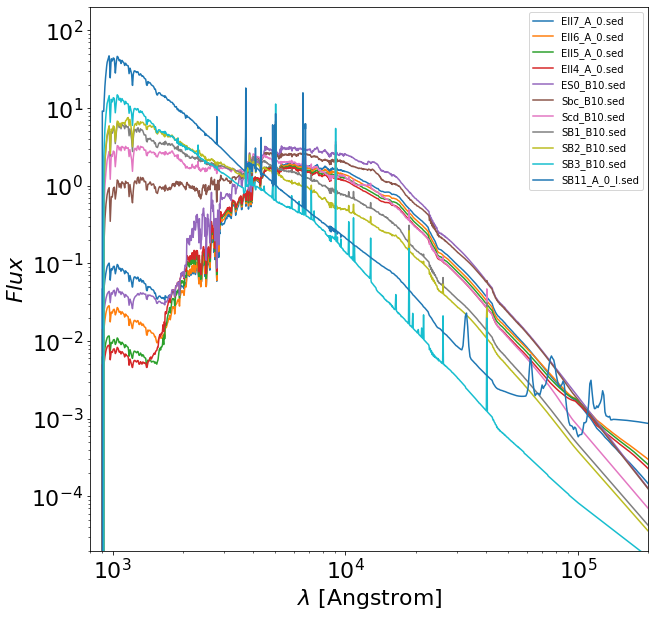

In [20]:
import numpy as np
fig,ax=plt.subplots(1,1,figsize=(10,10))
for i in range(len(seds_df.sed)):
    l,f=np.loadtxt(homedir+seds_df.sed[i],unpack=True)
    ax.plot(l,f,'-',label=seds_df.sed[i])
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim([800,2e5])
ax.set_ylim([2e-5,200])
ax.legend()
lsize=22
ax.set_xlabel(r'$\lambda$ [Angstrom]',fontsize=lsize)
ax.set_ylabel(r'$Flux$',fontsize=lsize)
ax.xaxis.set_tick_params(labelsize=lsize)
ax.yaxis.set_tick_params(labelsize=lsize)

Come possiamo vedere, i template ```Ell*``` sono caratteristici di galassie early type (che emettono prevalentemente alle lunghezze d'onda maggiori). Al contrario, le galassie spirali (```Sbc``` ed ```Scd```) o ancor piu' le galassie starburst (```SB*```) sono caratterizzate da una forte emissione anche alle lunghezze d'onda piu' piccole.

Assumiamo ora che la nostra sorgente sia una galassia starburst, ad esempio con una SED ben descritta dal template ```SB11_A_0_I```. Gli spettri in figura sono rest-frame, quindi devono essere traslati lungo l'asse $\lambda$ per ottenere la vera SED della sorgente. Questa operazione di per se' e' semplice, ma possiamo comunque affidarci ad un pacchetto python esistente che permette di manipolare le SED. Il pacchetto si chiama ```barak```:  

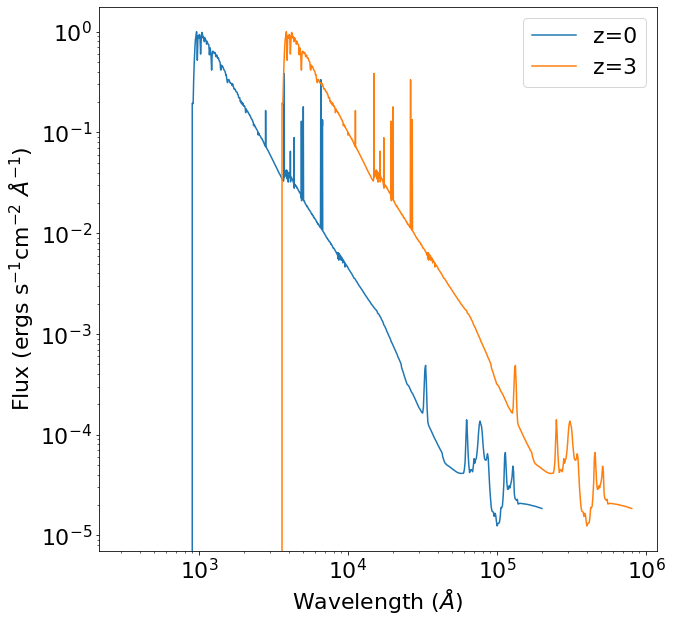

In [21]:
def sedplot(sed, ax, log=False, ymax=None, label='',**kwargs):
    fl = sed.fl
    if ymax is not None:
        fl = sed.fl / sed.fl.max() * ymax
    if log:
        ax.loglog(sed.wa, fl, label=label)
    else:
        ax.plot(sed.wa, fl, label=label)
    ax.set_xlabel('Wavelength ($\AA$)',fontsize=kwargs['fontsize'])
    ax.set_ylabel('Flux (ergs s$^{-1}$cm$^{-2}$ $\AA^{-1}$)',fontsize=kwargs['fontsize'])


import barak.sed as ss
l,f=np.loadtxt(homedir+seds_df.sed[i],unpack=True)
sed_0=ss.SED(wa=l, fl=f, z=0)
sed_z=sed_0.copy()
sed_z.redshift_to(zs)

lsize=22
kwargs = {"fontsize": lsize}
fig,ax = plt.subplots(1,1,figsize=(10,10))
sedplot(sed_0,log=True,ax=ax,label='z=0',ymax=1.,**kwargs)
sedplot(sed_z,log=True,ax=ax,label='z=3',ymax=1.,**kwargs)
ax.legend(fontsize=lsize)

ax.xaxis.set_tick_params(labelsize=lsize)
ax.yaxis.set_tick_params(labelsize=lsize)


```barak``` contiene anche alcune funzioni che ci permettono di calcolare, a partire dallo spettro della sorgente, il suo flusso (o la magnitudine) in bande arbitrarie. Supponiamo di usare Hubble per osservare la nostra sorgente nella banda F606W. Possiamo definire la ```passband``` opportuna in questo modo:   

In [22]:
filtern = 'BPZ/HST_ACS_WFC_F606W.res'
passband = ss.Passband(filtern)

Visualizziamo il filtro e la SED:

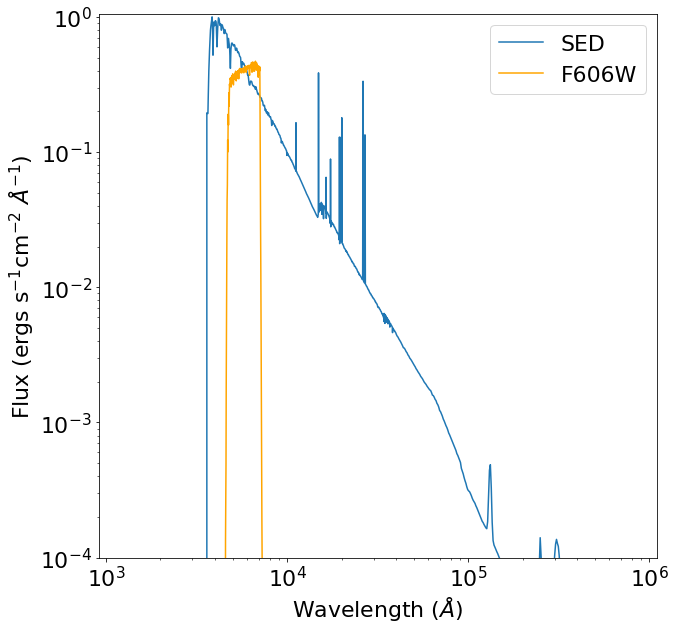

In [23]:
def bandplot(passband,ax, ymax=None, log=False, color='Orange', label=''):
    fl = passband.tr
    if ymax is not None:
        fl = passband.tr / passband.tr.max() * ymax
    if log:
        ax.loglog(passband.wa, fl, label=label, color=color)
    else:
        ax.plot(passband.wa, fl, label=label, color=color)

fig,ax = plt.subplots(1,1,figsize=(10,10))
sedplot(sed_z,log=True,ax=ax,label='SED',ymax=1.,**kwargs)
bandplot(passband,log=True,ax=ax,label='F606W')
ax.xaxis.set_tick_params(labelsize=lsize)
ax.yaxis.set_tick_params(labelsize=lsize)
ax.set_ylim([1e-4,1.05])
ax.legend(fontsize=lsize)

Al momento la SED ha una normalizzazione arbitraria. Immaginiamo di sapere la magnitudine della nostra sorgente in banda F606W. Supponiamo che questa magnitudine sia $m_{AB}(F606W)=25$. Con questa informazione, possiamo riscalare la SED in modo tale che il suo integrale nella banda passante restituisca il flusso corrispondente alla magnitudine stabilita: 

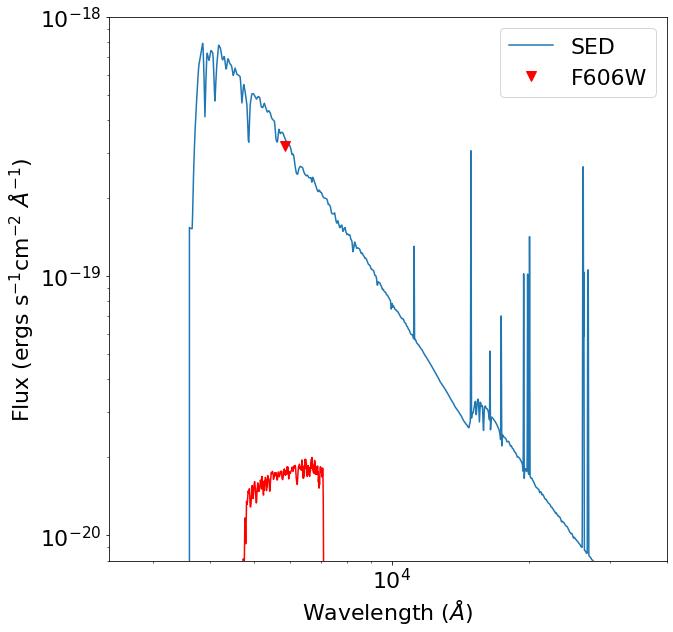

In [24]:
magAB_F606W=25
sed_z.normalise_to_mag(magAB_F606W,passband)

flux_0 = ss.mag2flux(magAB_F606W,passband)

fig,ax = plt.subplots(1,1,figsize=(10,10))
sedplot(sed_z,log=True,ax=ax,label='SED',**kwargs)
p=ax.plot(passband.effective_wa,flux_0,'v',color='red',label='F606W',markersize=10)
bandplot(passband,ymax=2e-20,ax=ax,log=True,color=p[0].get_color())
ax.xaxis.set_tick_params(labelsize=lsize)
ax.yaxis.set_tick_params(labelsize=lsize)
ax.set_xlim([2400,40000])
ax.set_ylim([8e-21,1e-18])
ax.legend(fontsize=lsize)

Una volta normalizzata la SED, possiamo calcolare flussi e magnitudini della sorgente in altre bande fotometriche. Per esempio, possiamo calcolare queste quantita' per le bande HST usate nelle osservazioni dei Frontier Fields:

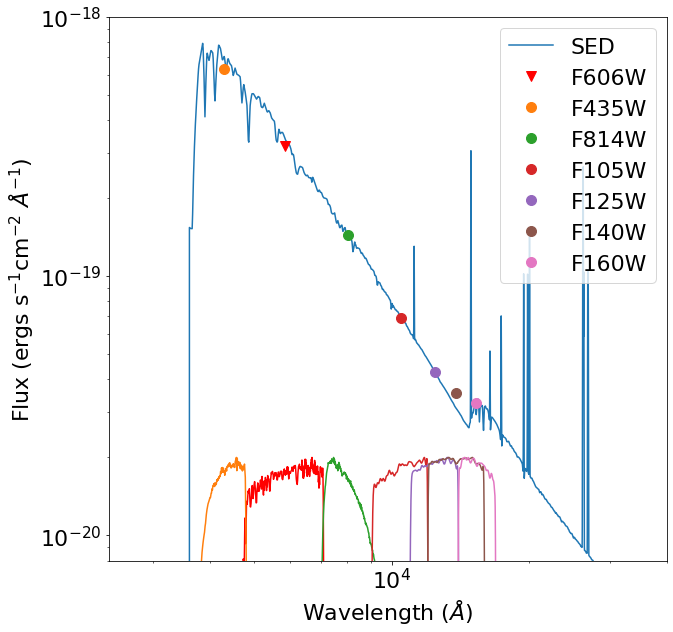

In [25]:
filtern_FF = ['BPZ/HST_ACS_WFC_F435W.res',
              'BPZ/HST_ACS_WFC_F814W.res',
              'BPZ/HST_WFC3_IR_F105W.res',
              'BPZ/HST_WFC3_IR_F125W.res',
              'BPZ/HST_WFC3_IR_F140W.res',
              'BPZ/HST_WFC3_IR_F160W.res']
labels = ['F435W', 'F814W', 'F105W', 'F125W', 'F140W', 'F160W']
fig,ax = plt.subplots(1,1,figsize=(10,10))
sedplot(sed_z,log=True,ax=ax,label='SED',**kwargs)
p=ax.plot(passband.effective_wa,flux_0,'v',color='red',label='F606W',markersize=10)
bandplot(passband,ymax=2e-20,ax=ax,log=True,color=p[0].get_color())
i=0
kp=[]
kp.append({'band': 'F606W', 'mag': magAB_F606W, 'F_nu': ss.flambda_to_fnu(passband.effective_wa,flux_0)})
for filtern_ in filtern_FF:
    passband_ = ss.Passband(filtern_)
    flux_ = sed_z.calc_flux(passband_)
    p=ax.plot(passband_.effective_wa,flux_,'o',label=labels[i],markersize=10)
    bandplot(passband_,ymax=2e-20,ax=ax,log=True,color=p[0].get_color())
    mag_ = sed_z.calc_mag(passband_,system='AB')
    kp.append({'band': labels[i], 'mag': mag_, 'F_nu': ss.flambda_to_fnu(passband_.effective_wa,flux_)})
    i+=1

ax.xaxis.set_tick_params(labelsize=lsize)
ax.yaxis.set_tick_params(labelsize=lsize)
ax.set_xlim([2400,40000])
ax.set_ylim([8e-21,1e-18])
ax.legend(fontsize=lsize,loc=1)

df_=pd.DataFrame(kp)

Le magnitudini e i flussi ($F_\nu$) in tutte queste bande sono quindi:

In [26]:
df_

,band,mag,F_nu
0,F606W,25.000000,3.630781e-30
1,F435W,24.921210,3.868476e-30
2,F814W,25.167462,3.070527e-30
3,F105W,25.375046,2.537389e-30
4,F125W,25.530507,2.206052e-30
5,F140W,25.495313,2.270360e-30
6,F160W,25.380894,2.541851e-30


# Produrre immagini HST-like

Nota la magnitudine di una sorgente in una banda fotometrica, dobbiamo calcolare il numero di conteggi che corrispondono a quella magnitudine sul detector dello strumento. Continuiamo a fare riferimento ad HST e alle bande dei Frontier Fields. Come visto precedentemente, per calcolare i conteggi, ci serve lo zero-point. Quest'ultimo puo' essere ricavato dagli header delle immagini HST  nelle quali vogliamo inserire la sorgente distorta dall'ammasso ([vedi qui](https://www.stsci.edu/hst/instrumentation/acs/data-analysis/zeropoints)). In alternativa, possiamo calcolarlo usando le funzioni contenute nel pacchetto ```acstools``` ([vedi qui](https://acstools.readthedocs.io/en/latest/acszpt.html)). In questo esempio lavoriamo con l'immagine di MACSJ1206 in banda F814W:

In [27]:
from acstools import acszpt

def flux2counts(flux_hst, header_hst):
    '''
    Convert the flux F_nu into HST counts (e-/s)
    :param flux_hst: HST flux F_nu
    :param header_hst: HST header object
    :return: HST counts in e-/s
    '''

    abzp_hst = -2.5 * np.log10(header_hst['PHOTFLAM']) - 5 * np.log10(header_hst['PHOTPLAM']) - 2.4079

    try:
        date = header_hst['DATE'].split('T')[0]
        detector = header_hst['DETECTOR']
        filter = header_hst['FILTER1']

        if filter == 'CLEAR1L':
            filter = header_hst['FILTER2']
        q = acszpt.Query(date=date, detector=detector, filt=filter)
        abzp_table = q.fetch()['ABmag'][0].value

        if np.abs(abzp_table - abzp_hst) > 0.001:

            print('WARNING: zp in the database differ from the zp computed from the header. Database: ' + str(abzp_table) +', header: '+str(abzp_hst))
    except:
        pass

    cost = (abzp_hst + 48.60) / 2.5
    counts_hst = flux_hst * 10**cost

    return counts_hst

hst_image = "hlsp_clash_hst_acs_macs1206_f814w_v1_drz.fits"
import astropy.io.fits as fits

hdul=fits.open(hst_image)
header=hdul[0].header

dsel=df_.loc[df_['band'] == 'F814W']

counts=flux2counts(dsel['F_nu'].values[0],header)
print (('Counts from source: %8.4f e-/s') % (counts))

INFO:acszpt.Query:Checking inputs...
INFO:acszpt.Query:Submitting request to https://acszeropoints.stsci.edu/results_single/?date1=2011-08-14&detector=WFC&WFC_filter=F814W
INFO:acszpt.Query:Parsing the response and formatting the results...


Counts from source:   2.0163 e-/s


Questi conteggi sono **unlensed** e li possiamo usare per ri-normalizzare il flusso del ```sersic``` model usato per descrivere la sorgente (nota che il metodo appena descritto per convertire flussi in conteggi e' equivalente a quello implementato in ```observation.mag2counts```): 

In [53]:
kwargs_source_light={
    'n': 1.0, # sersic index
    're': 0.2, # effective radius
    'q': 1.0, # axis ratio
    'pa': np.pi/4., # position angle
    'ys1': xc.mean()+0.3, # position x (on the source plane)
    'ys2': yc.mean()+0.4, # position y (on the lens plane)
    'flux': counts, # flux of the source (in counts/s)
    'zs': zs
}
se=sersic(size=fov_ray, Npix=df.nray,gl=df,**kwargs_source_light)

Ora assegniamo all'immagine della sorgente un WCS e creiamo una hdu contenente immagine ed header:

In [54]:
# il centro della griglia simulata (nray/2,nray/2) corrisponde alle coordinate specificate in coords[0]
position = SkyCoord(coords[0], frame='fk5',unit="deg")
# la pixel scale e' fov_ray/(npix-1)
pixscale=fov_ray/(df.nray-1)/3600.0 # in gradi

hdu_sim = pyfits.PrimaryHDU(se.image)

def formatHeader(hdu,ra_c,dec_c,pix,npix):
    hdu.header['RADESYS'] = 'ICRS    '
    hdu.header['CTYPE1'] = 'RA---TAN'
    hdu.header['CUNIT1'] = 'deg   '
    hdu.header['CTYPE2'] = 'DEC--TAN'
    hdu.header['CUNIT2'] = 'deg   '
    hdu.header['CD1_1'] = -pix
    hdu.header['CD1_2'] = 0.000000000000E+00
    hdu.header['CD2_1'] = 0.000000000000E+00
    hdu.header['CD2_2'] = pix
    hdu.header['NAXIS'] = 2
    hdu.header['CRPIX1'] = npix//2
    hdu.header['CRPIX2'] = npix//2
    hdu.header['CRVAL1'] = ra_c
    hdu.header['CRVAL2'] = dec_c
    hdu.header['NAXIS1'] = npix
    hdu.header['NAXIS2'] = npix
    
formatHeader(hdu_sim,position.ra.degree,position.dec.degree,pixscale,df.nray)

In [55]:
hdu_sim.header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 2000                                                  
NAXIS2  =                 2000                                                  
EXTEND  =                    T                                                  
RADESYS = 'ICRS    '                                                            
CTYPE1  = 'RA---TAN'                                                            
CUNIT1  = 'deg     '                                                            
CTYPE2  = 'DEC--TAN'                                                            
CUNIT2  = 'deg     '                                                            
CD1_1   = -2.7791673614585E-05                                                  
CD1_2   =                  0

Ritagliamo l'immagine in banda F814W in modo consistente:

INFO:astropy:
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                
INFO:astropy:
        Inconsist

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
(5000, 5000)
INFO: 


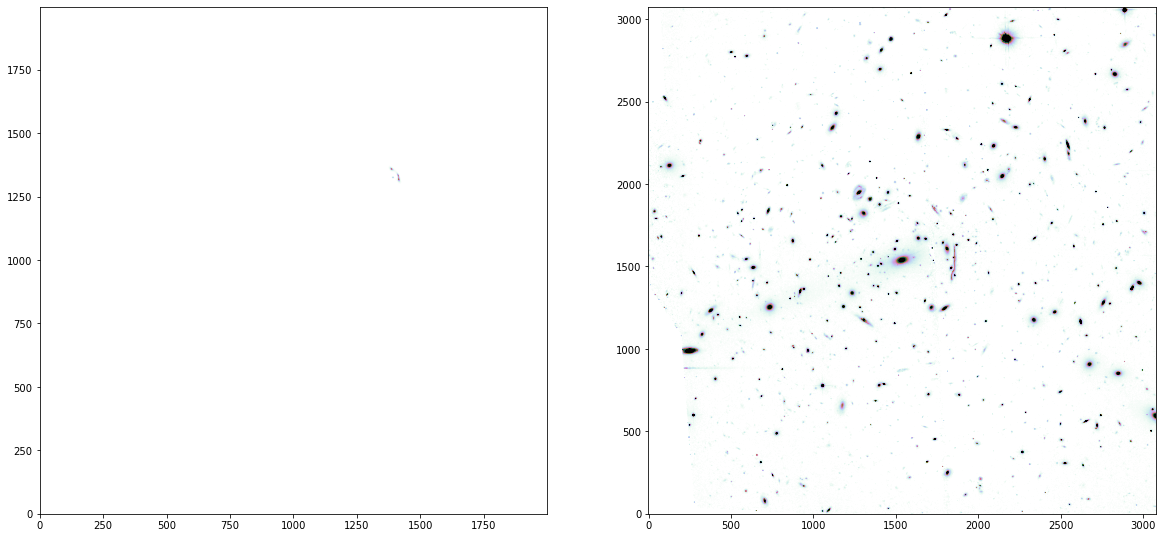

In [56]:
def cutout_image(image,coords,fov=200.0):

    hdul=pyfits.open(image)
    w = WCS(image)

    image_=hdul[0].data
    print (image_.shape)

    size = u.Quantity((fov, fov), u.arcsec)
    position = SkyCoord(coords, frame='fk5',unit="deg")
    cutout_ = Cutout2D(image_, position, size, wcs=w)
    w_up=cutout_.wcs
    header_ = w_up.to_header()
    hdu_hst = pyfits.PrimaryHDU(cutout_.data,header=header_)
    return hdu_hst

hdu_hst=cutout_image(hst_image,coords[0],fov=fov_ray)

fig,ax=plt.subplots(1,2,figsize=(20,10))
ax[0].imshow(hdu_sim.data,origin='lower',cmap='cubehelix_r')
ax[1].imshow(hdu_hst.data,origin='lower',vmax=hdu_hst.data.max()*0.001,vmin=0.0,cmap='cubehelix_r')


Per combinare le due immagini dobbiamo riproiettare l'immagine simulata sull'header dell'immagine vera. A questo scopo possiamo usare il package ```reproject```: 

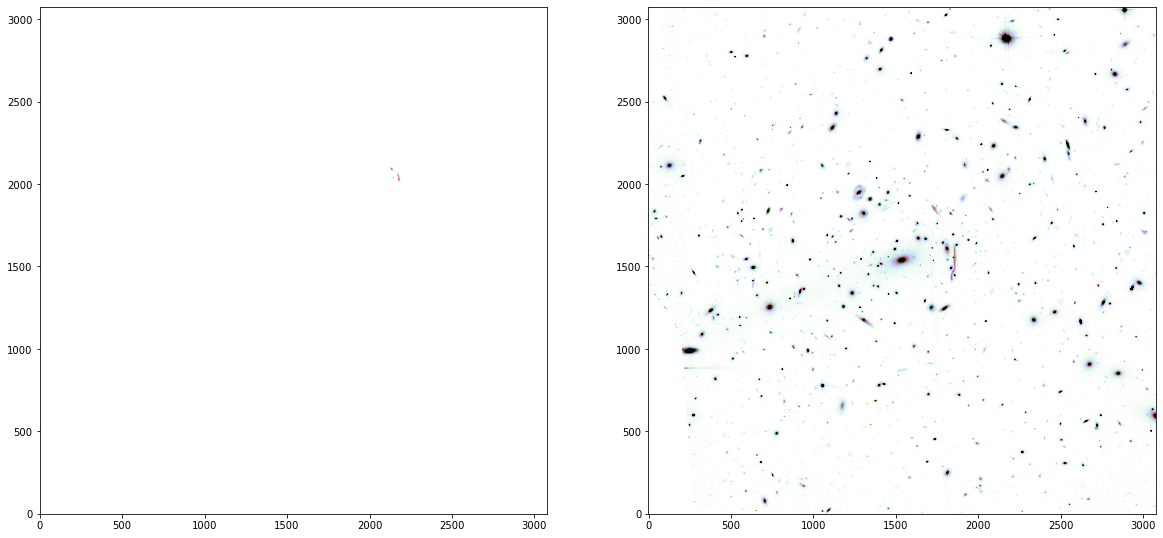

In [57]:
from reproject import reproject_exact, reproject_interp
# slower, but more precise:
repr_image, footprint = reproject_exact(hdu_sim, hdu_hst.header)
# faster option:
#repr_image, footprint = reproject_interp(hdu_sim, hdu_hst.header)
fig,ax=plt.subplots(1,2,figsize=(20,10))
ax[0].imshow(repr_image,origin='lower',cmap='cubehelix_r')
ax[1].imshow(hdu_hst.data,origin='lower',vmax=hdu_hst.data.max()*0.001,vmin=0.0,cmap='cubehelix_r')

Finally, we combine the images:

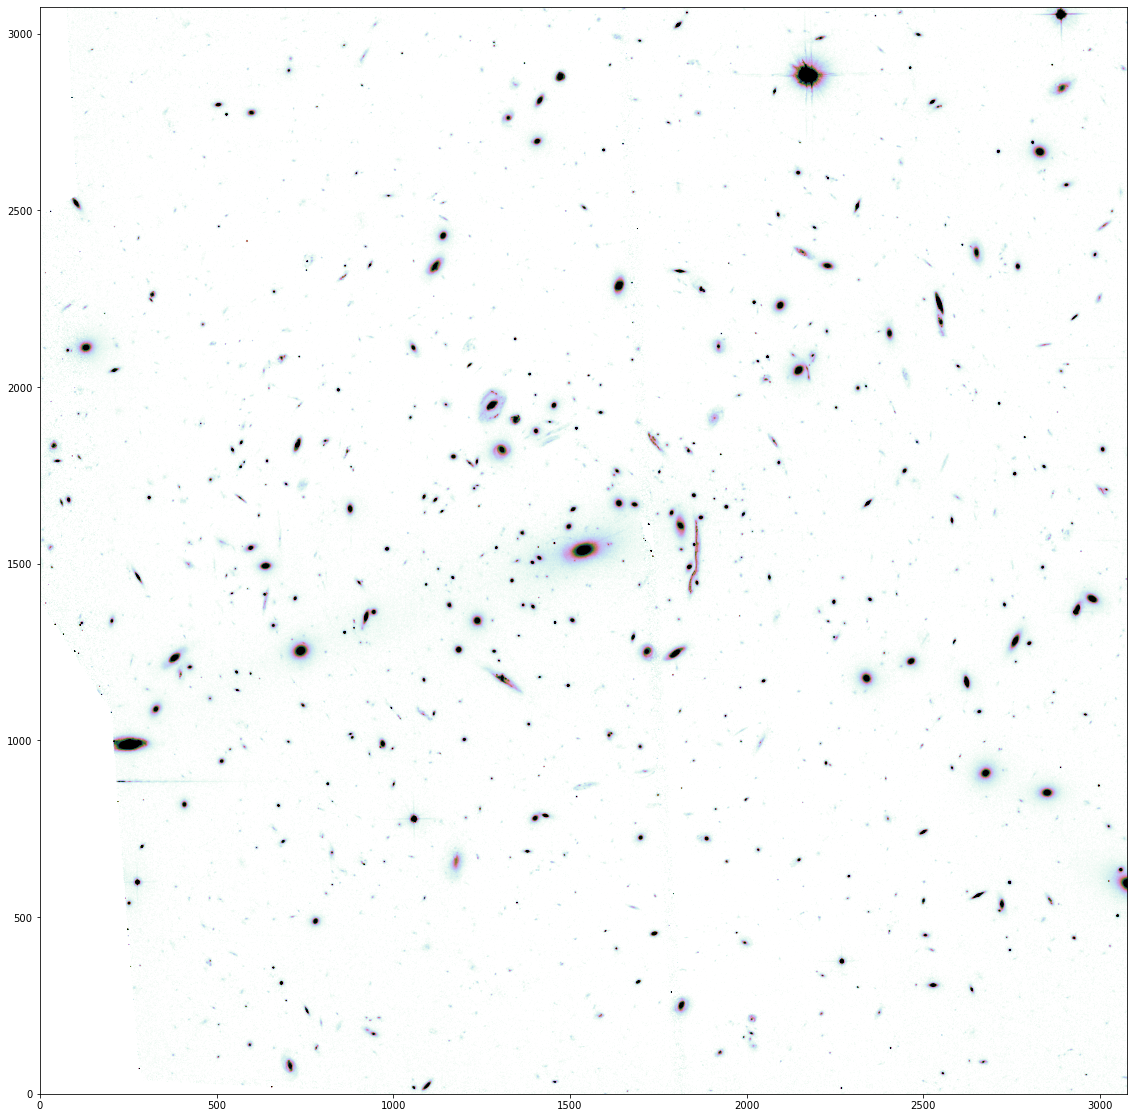

In [58]:
hdu_hst.data=hdu_hst.data+repr_image
fig,ax=plt.subplots(1,1,figsize=(20,20))
ax.imshow(hdu_hst.data,origin='lower',vmax=hdu_hst.data.max()*0.001,vmin=0.0,cmap='cubehelix_r')

Se la forma della sorgente non cambia in funzione della lunghezza d'onda, non serve ripetere tutta la procedura per simulare osservazioni in altre bande fotometriche. Sara' solo necessario riscalare le immagini in base ai rapporti di flusso della sorgente tra le nuove bande e la vecchia. Ad esempio, per simulare un'osservazione nelle bande F435W e F606W, possiamo fare cosi':  

In [59]:
dsel=df_.loc[df_['band'] == 'F435W']
hst_image_f435w = "hlsp_clash_hst_acs_macs1206_f435w_v1_drz.fits"
hdul=fits.open(hst_image_f435w)
header_f435w=hdul[0].header
counts_f435w=flux2counts(dsel['F_nu'].values[0],header_f435w)
f_f435w=counts_f435w/counts
repr_image_f435w=repr_image*f_f435w
hdu_hst_f435w=cutout_image(hst_image_f435w,coords[0],fov=fov_ray)
hdu_hst_f435w.data=hdu_hst_f435w.data+repr_image_f435w

dsel=df_.loc[df_['band'] == 'F606W']
hst_image_f606w = "hlsp_clash_hst_acs_macs1206_f606w_v1_drz.fits"
hdul=fits.open(hst_image_f606w)
header_f606w=hdul[0].header
counts_f606w=flux2counts(dsel['F_nu'].values[0],header_f606w)
f_f606w=counts_f606w/counts
repr_image_f606w=repr_image*f_f606w
hdu_hst_f606w=cutout_image(hst_image_f606w,coords[0],fov=fov_ray)
hdu_hst_f606w.data=hdu_hst_f606w.data+repr_image_f606w

INFO:astropy:
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                
INFO:astropy:
        Inconsist

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
(5000, 5000)
INFO: 


INFO:astropy:
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                
INFO:astropy:
        Inconsist

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
(5000, 5000)
INFO: 


Proviamo a fare un cut-out di $10\times 10$ arcsec della galassia lente dalle immagini HST:

In [24]:
coords_ggsl = '181.5548881 -8.795808613'

def cutout_hdu(hdu,coords,fov=200.0):

    w=WCS(hdu.header)
    image_=hdu.data
    size = u.Quantity((fov, fov), u.arcsec)
    position = SkyCoord(coords, frame='fk5',unit="deg")
    cutout_ = Cutout2D(image_, position, size, wcs=w)
    w_up=cutout_.wcs
    header_ = w_up.to_header()
    hdu_hst = pyfits.PrimaryHDU(cutout_.data,header=header_)
    return hdu_hst


ggsl_f435w=cutout_hdu(hdu_hst_f435w,coords_ggsl,fov=10)
ggsl_f606w=cutout_hdu(hdu_hst_f606w,coords_ggsl,fov=10)
ggsl_f814w=cutout_hdu(hdu_hst,coords_ggsl,fov=10)

Infine, creiamo un'immagine RGB combinando i tre canali:

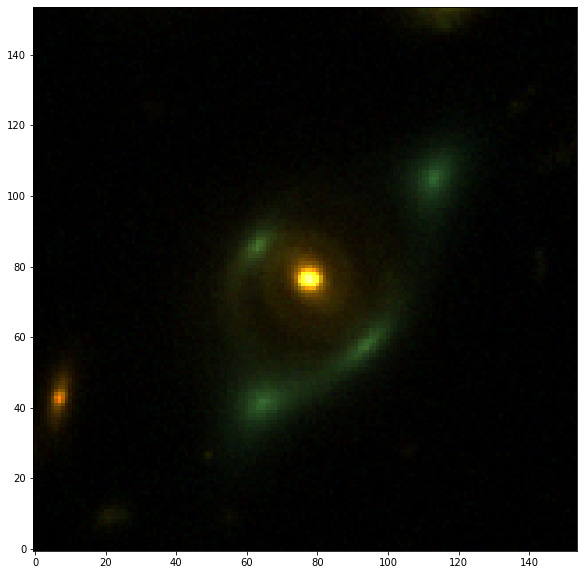

In [25]:
Z = np.dstack((ggsl_f814w.data,ggsl_f606w.data,ggsl_f435w.data))#.transpose()
Z.shape
fig,ax=plt.subplots(1,1,figsize=(10,10))
ax.imshow(Z,origin='lower')

In [60]:
coords_ggsl = '181.5548881 -8.795808613'
pos=SkyCoord(coords[0], frame='fk5',unit="deg")
idcl=4
x,y=df.getCritPoints(cl[idcl])
x1=x.mean()
x2=y.mean()
ref_ra=pos.ra.value
ref_dec=pos.dec.value

def cutout_hdu(hdu,coords,fov=200.0):

    w=WCS(hdu.header)
    image_=hdu.data
    size = u.Quantity((fov, fov), u.arcsec)
    position = SkyCoord(coords, frame='fk5',unit="deg")
    cutout_ = Cutout2D(image_, position, size, wcs=w)
    w_up=cutout_.wcs
    header_ = w_up.to_header()
    hdu_hst = pyfits.PrimaryHDU(cutout_.data,header=header_)
    return hdu_hst


def arcsec2ra(x,y,RA_REF,DEC_REF):
    RA=-x/(np.cos(np.deg2rad(DEC_REF))*3600.0)+RA_REF
    DEC=y/3600.0+DEC_REF
    return RA,DEC

ggsl_ra,ggsl_dec=arcsec2ra(x1,x2,ref_ra,ref_dec)
coords_=str(ggsl_ra)+" "+str(ggsl_dec)
coords_

'181.5395325128041 -8.791788016881032'

/Users/massimo/.local/lib/python3.7/site-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in sqrt
  import sys


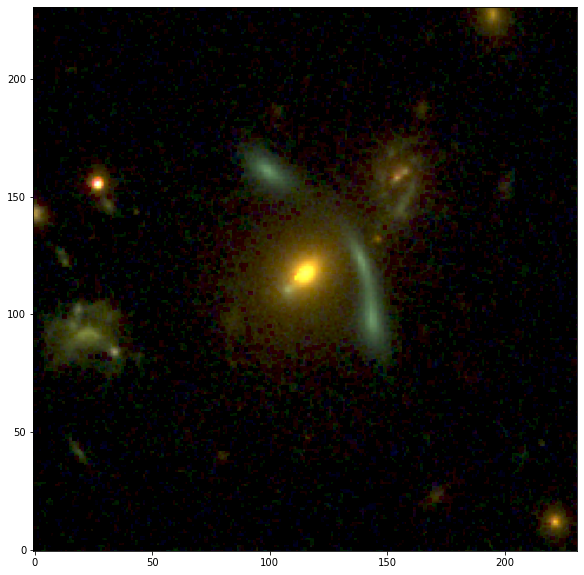

In [70]:
ggsl_f435w=cutout_hdu(hdu_hst_f435w,coords_,fov=15)
ggsl_f606w=cutout_hdu(hdu_hst_f606w,coords_,fov=15)
ggsl_f814w=cutout_hdu(hdu_hst,coords_,fov=15)
Z = np.dstack((ggsl_f814w.data,ggsl_f606w.data,ggsl_f435w.data))#.transpose()
Z.shape
fig,ax=plt.subplots(1,1,figsize=(10,10))
ax.imshow(np.sqrt(Z),origin='lower')
fig.savefig('example.png')

In [39]:
# start from scratch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pyfits

import random

import pyLensLib
from pyLensLib.deflector import deflector
from pyLensLib.observation import observation
from pyLensLib.sersic import sersic
import time

from astropy.cosmology import FlatLambdaCDM
from astropy.coordinates import SkyCoord, funcs
from astropy.wcs import WCS
from astropy import units as u
from astropy.nddata import Cutout2D
import astropy.io.fits as fits

from reproject import reproject_exact, reproject_interp
from shapely.geometry import Polygon, Point
import barak.sed as ss
co = FlatLambdaCDM(Om0 = 0.3, H0 = 70.0)

#funzione che crea deflettore
def create_mini_deflector(nick, filex, filey, zl, zs, co, zsnorm = 1.0):

    angx_hd = pyfits.open(filex)
    angy_hd = pyfits.open(filey)

    try:
        if (angx_hd[0].header['CDELT1'] == 1.0):
            pixels = -3600.0*angx_hd[0].header['CD1_1']
        else:
            pixels = -3600.0*angx_hd[0].header['CDELT1']
    except:
        pixels = -3600.0*angx_hd[0].header['CD1_1'] 
        
    a1 = angx_hd[0].data
    a2 = angy_hd[0].data
    
    npix = a1.shape[0]
    fov_ray = pixels*(npix-1)
    

    kwargs_def = {'zl': zl, 'zs': zsnorm}
    df = deflector(co, angx = a1, angy = a2, **kwargs_def)

    #coordinate di punti in cui sono calcolati a1, a2
    theta = np.linspace(-fov_ray/2., fov_ray/2., npix)
    df.setGrid(theta = theta, compute_potential = False)

    #definiamo il redshift delle sorgenti che dovremo distorcere
    df.change_redshift(zs)

    return df, fov_ray 

#conversione positione in arcsec in ra, dec
def arcsec2ra(x, y, RA_REF, DEC_REF):

    RA = -x/(np.cos(np.deg2rad(DEC_REF))*3600.0) + RA_REF
    DEC = y/3600.0 + DEC_REF

    return RA, DEC

#funzione che calcola la sed da associare alla sorgente a partire dalla sua magnitudine in una data banda
#come esempio nel codice c'è f606w
def sed_creator(mag_norm, filters, labels):
    path_to_sed = '/Users/massimo/CODES/bpz-1.99.3/SED/'
    sed_list = path_to_sed + 'eB11.list'
    seds_df = pd.read_csv(sed_list, header = None, delim_whitespace = True)
    seds_df.columns = ['sed']
    #print(seds_df)
    #scelgo casualmente il template da usare tra quelli disponibili
    seds = seds_df['sed']
    sed = 'SB11_A_0_l.sed'#random.choice(seds)

    l, f = np.loadtxt(path_to_sed + sed, unpack = True) #scelgo una delle sed
    sed_0 = ss.SED(wa = l, fl = f, z = 0)
    sed_z = sed_0.copy()
    sed_z.redshift_to(zs) #la sposto a redshift della sorgente

    #normalizzo la sed alla magnitudine che conosco (banda 606 come esempio)
    filter_norm = 'BPZ/HST_ACS_WFC_F606W.res'
    passband_norm = ss.Passband(filter_norm)
    magAB_norm = 25  
    sed_z.normalise_to_mag(magAB_norm, passband_norm)
    #converto magnitudine in flusso
    flux_0 = ss.mag2flux(magAB_norm, passband_norm)

    #creo dataframe con info di flusso e magnitudine della sorgente nelle bande a cui sono interessata
    i = 0
    kp = []
    kp.append({'band': 'F606W', 'mag': magAB_norm, 'F_nu': ss.flambda_to_fnu(passband_norm.effective_wa, flux_0)})
    for filtern in filters:
        passband_ = ss.Passband(filtern)
        flux_ = sed_z.calc_flux(passband_)
        #p = ax.plot(passband_.effective_wa, flux_, 'o', label = labels[i], markersize = 10)
        #bandplot(passband_, ymax = 2e-20, ax = ax, log = True, color = p[0].get_color())
        mag_ = sed_z.calc_mag(passband_, system = 'AB')
        kp.append({'band': labels[i], 'mag': mag_, 'F_nu': ss.flambda_to_fnu(passband_.effective_wa, flux_)})
        i+=1
    #print(kp)

    df_sedflux = pd.DataFrame(kp)
    #print(df_sedflux)
    return df_sedflux


#funzione per convertire flusso in conteggi da sommare all'immagine hst
def flux2counts(flux_hst, header_hst):
    '''
    Convert the flux F_nu into HST counts (e-/s)
    :param flux_hst: HST flux F_nu
    :param header_hst: HST header object
    :return: HST counts in e-/s
    '''

    #calcolo zeropoint dell'immagine dall'header
    abzp_hst = -2.5 * np.log10(header_hst['PHOTFLAM']) - 5 * np.log10(header_hst['PHOTPLAM']) - 2.4079

    cost = (abzp_hst + 48.60) / 2.5
    counts_hst = flux_hst * 10**cost

    return counts_hst

#funzione per fare header di immagine simulata
def formatHeader(hdu, ra_c, dec_c, pix, npix):
    hdu.header['RADESYS'] = 'ICRS    '
    hdu.header['CTYPE1'] = 'RA---TAN'
    hdu.header['CUNIT1'] = 'deg   '
    hdu.header['CTYPE2'] = 'DEC--TAN'
    hdu.header['CUNIT2'] = 'deg   '
    hdu.header['CD1_1'] = -pix
    hdu.header['CD1_2'] = 0.000000000000E+00
    hdu.header['CD2_1'] = 0.000000000000E+00
    hdu.header['CD2_2'] = pix
    hdu.header['NAXIS'] = 2
    hdu.header['CRPIX1'] = npix//2
    hdu.header['CRPIX2'] = npix//2
    hdu.header['CRVAL1'] = ra_c
    hdu.header['CRVAL2'] = dec_c
    hdu.header['NAXIS1'] = npix
    hdu.header['NAXIS2'] = npix
    

#funzione per calcolare psf scale che serve nella convoluzione di immagine simulata con filtro hst
def get_psf_scale(image):
    psf_scale = image.header["PIXSCALE"]
    return psf_scale


#funzione per fare cutout di immagine HST
def cutout_image(image, coords, fov = 200.0):

    hdul = pyfits.open(image)
    w = WCS(image)

    image_ = hdul[0].data

    size = u.Quantity((fov, fov), u.arcsec)
    position = SkyCoord(coords, frame = 'fk5',unit = "deg")
    cutout_ = Cutout2D(image_, position, size, wcs = w)
    w_up = cutout_.wcs
    header_ = w_up.to_header()
    hdu_hst = pyfits.PrimaryHDU(cutout_.data, header = header_)

    return hdu_hst

#funzione per fare cutout di hdu (ovvero, di immagine simulata
def cutout_hdu(hdu, coords, fov = 200.0):

    w = WCS(hdu.header)
    image_ = hdu.data
    size = u.Quantity((fov, fov), u.arcsec)
    position = SkyCoord(coords, frame = 'fk5', unit = "deg")
    cutout_ = Cutout2D(image_, position, size, wcs = w)
    w_up = cutout_.wcs
    header_ = w_up.to_header()
    hdu_hst = pyfits.PrimaryHDU(cutout_.data, header = header_)

    return hdu_hst

#funzione per trovare punti all'interno del buffer attorno alla caustica
def get_positions(caustic, re): 
    #definisco i punti che fanno parte della caustica e ne creo lista
    x, y = df.getCausticPoints(caustic)
    #print(x)
    #print(y)
    point_list = []  
    for j, x_point in enumerate(x):
        object_list = [x_point, y[j]]
        point_list.append(object_list)
    #print(pointlist)
        
    #trasformo coordinate in poligono e definisco buffer
    mp = Polygon([[coords[0], coords[1]] for coords in point_list]).exterior
    #print(mp)
    t = Polygon(mp.buffer(re).exterior)
    xt, yt = t.exterior.coords.xy #coordinate esterne del poligono
    #print(xt, yt)
 
    #estraggo posizioni causali nel buffer e le salvo in una lista
    num_points = 1 #come esempio genero una sola posizione
    points = []
    while len(points) < num_points:
        random_point = Point([np.random.uniform(np.min(xt), np.max(xt)), np.random.uniform(np.min(yt), np.max(yt))]) 
        if (random_point.within(t)): #controllo che il punto sia nel buffer
             points.append(random_point)
    
    x_source = []
    y_source = []
    for i in range(len(points)): 
        x_source.append(points[i].x)
        y_source.append(points[i].y)
    
    x_source = np.array(x_source)
    y_source = np.array(y_source)

    #fig, ax = plt.subplots(1, 1, figsize = (10, 7))   
    #ax.plot(np.array(x), np.array(y), '-' , color = 'blue', label = 'caustic')
    #ax.plot(np.array(xt), np.array(yt), '-', color = 'red', label = 'buffer')
    #ax.set_xticks([]) 
    #ax.set_yticks([]) 
    #ax.plot(x_source, y_source, marker = 'x', color = 'green', linestyle = 'None', label = 'source position')
    #ax.set_aspect('equal')

    #plt.legend(fontsize = 18)
    #plt.tight_layout()
    #plt.savefig("buffer_prova_" + str(72) + ".pdf")

    return x_source, y_source 


#funzione per simulare l'evento di GGSL
#MEMO: 
#cluster_nick fa riferimento al cluster in analisi
#filters_list è l'insieme dei filtri da usare 
#path_to_cluster è il path fino alla cartella precedente a quella in cui c'è un dato filtro 
def source_maker(df, zs, cluster_nick, filters_list, path_to_cluster, fov_ray, coords, path_to_images, path_to_psf, filters, fov = 200.0):

    #dal deflettore calcolo le linee critiche tangenziali e radiali, le mappo nelle caustiche e ne faccio una lista
    tl = df.tancl()
    rl = df.radcl()
    caut = df.getCaustics(tl)
    caur = df.getCaustics(rl)
    caustics = np.append(caut, caur)
    critical_lines = np.append(tl, rl)
    #considero la i-esima linea critica (idcl):
    for idcl in range(1,5):  #ci andrebbe len(caustics), ma scelgo una sola caustica come esempio
        re = 0.2 #raggio effettivo della galassia in arcsec
        #definisco posizione della sorgente in un buffer attorno alla caustica
        x_s, y_s = get_positions(caustics[idcl], re)
 
        ### La mag della source dovrebbe essere scelta in modo da riflettere la distribuzione vera delle sorgenti ma ok
        mag_source = 21.0
        #creo la sed della sorgente
        filter_labels = ['F435W', 'F606WW', 'F814W']
        data_sed_source = sed_creator(mag_source, filters, filter_labels)

        hdul = fits.open(path_to_cluster[0]) 
        header = hdul[0].header 
        dsel = data_sed_source.loc[data_sed_source['band'] == filter_labels[0]]
        counts = flux2counts(dsel['F_nu'].values[0], header)
        #print (('Counts from source: %8.4f e-/s') % (counts))

        ob = observation(size = fov_ray, Npix = df.nray, zp = 23.9, texp = 565*4, bkg = 22.0)

        for j, x_source in enumerate(x_s): #ciclo al momento inutile perchè ho generato un solo punto
            #specifichiamo le caratteristiche della sorgente 
            kwargs_source_light = {
                'n': 1.0, #sersic index
                're': re, #effective radius
                'q': 1.0, #axis ratio
                'pa': np.pi/4., #position angle
                'ys1': x_source, #position x (on the source plane)
                'ys2': y_s[j], #position y (on the lens plane)
                'flux': counts, #flux of the source (in counts/s)
                'zs': zs
            }
            se = sersic(size = fov_ray, Npix = df.nray, gl = df, **kwargs_source_light)
            lensed_image = se.image

            #xc, yc = df.getCritPoints(tl[idcl])
            #fig , ax = plt.subplots(1, 1, figsize = (10, 10))
            #ax.imshow(se.image, origin = 'low', extent = [-100, 100, -100, 100], vmax = se.image.max()*0.5, cmap = 'gray_r')
            #ax.plot(xc, yc, '-', color = 'red')
            #ax.plot(xc.mean(), yc.mean(), '.', color = 'blue')
            #plt.savefig('prova_sim_'+str(idcl)+'.pdf')

            #associamo WCS all'immagine simulata e creiamo il suo hdu
            #il centro della griglia simulata (nray/2,nray/2) corrisponde alle coordinate specificate in coords[0]
            position = SkyCoord(coords[0], frame = 'fk5', unit = "deg")
            ref_ra = position.ra.value
            ref_dec = position.dec.value
            #la pixel scale e' fov_ray/(npix-1)
            pixscale = fov_ray/(df.nray - 1)/3600.0 # in gradi
            hdu_sim = pyfits.PrimaryHDU(lensed_image)
            formatHeader(hdu_sim, position.ra.degree, position.dec.degree, pixscale, df.nray) 


            #scegliamo posizione del cutout come centro della linea critica in ra, dec
            x_crit, y_crit = df.getCritPoints(critical_lines[idcl])
            x_ggsl = x_crit.mean() 
            y_ggsl = y_crit.mean()
            ggsl_ra, ggsl_dec = arcsec2ra(x_ggsl, y_ggsl, ref_ra, ref_dec)
            #coords_ggsl = [ggsl_ra, ggsl_dec]
            coords_ggsl = str(ggsl_ra)+" "+str(ggsl_dec)

            #facciamo cutout di 10 arcsec di immagine hst e simulata
            fov_cutout = 10 #arcsec
            ggsl_f = cutout_hdu(hdu_sim, coords_ggsl, fov = fov_cutout)
            hdu_hst= cutout_image(path_to_cluster[0], coords_ggsl, fov = fov_cutout)

            #proiettiamo immagine simulata sull'header
            repr_image, footprint = reproject_exact(hdu_sim, hdu_hst.header)

            #convolvo immagine simulata con filtro psf
            psf_image = pyfits.open(path_to_psf[0])
            psf_scale = get_psf_scale(psf_image[0])
            lensed_image_conv = ob.convolve_psf(repr_image, psf_image[0].data, psf_scale)

            #ricaviamo immagine finale prima nel filtro 814 e poi in tutti gli altri
            hdu_hst.data = hdu_hst.data + lensed_image_conv

            ggsl_tot = [hdu_hst]
            #calcolo evento in altri filtri 
            for i in range(len(filter_labels)-1):
                #calcolo conteggi in altro filtro 
                dsel = data_sed_source.loc[data_sed_source['band'] == filter_labels[i+1]]
                hdul = fits.open(path_to_clusters[i+1])
                header_f = hdul[0].header
                counts_f = flux2counts(dsel['F_nu'].values[0], header_f)
                #rinormalizzo immagine simulata a nuovi conteggi 
                f_f = counts_f/counts
                repr_image_f = repr_image*f_f
                #faccio cutout immagine dell'ammasso 
                hdu_hst_f = cutout_image(path_to_clusters[i+1], coords_ggsl, fov = fov_cutout)

                #convolvo nuova immagine con il suo filtro
                psf_image_f = pyfits.open(path_to_psf[i+1])
                psf_scale_f = get_psf_scale(psf_image_f[0])
                lensed_image_conv_f = ob.convolve_psf(repr_image_f, psf_image_f[0].data, psf_scale_f)

                ggsl_f.data = hdu_hst_f.data + lensed_image_conv_f
                ggsl_tot.append(ggsl_f) 

            
            Z = np.dstack((ggsl_tot[2].data, ggsl_tot[1].data, ggsl_tot[0].data))
            fig, ax = plt.subplots(1, 1, figsize = (10, 10))
            ax.imshow(Z, origin='lower')
            plt.savefig("final_cutout" + str(idcl) + ".pdf")

In [19]:
# Usiamo le informazioni specificate sopra per costruire i nomi dei files da leggere:
filex = path_to_angles[0]+cluster[0]+'_angx.fits'
filey = path_to_angles[0]+cluster[0]+'_angy.fits'
# costruiamo il deflettore
zs=3

df, fov_ray = create_mini_deflector(nick = cluster_rgb[0], filex = filex, filey = filey, co = co, zl = zl[0], zs = zs)

In [28]:
path_to_clusters = ['hlsp_clash_hst_acs_macs1206_f435w_v1_drz.fits', 
                    'hlsp_clash_hst_acs_macs1206_f606w_v1_drz.fits', 
                    'hlsp_clash_hst_acs_macs1206_f814w_v1_drz.fits'] 


paths_to_psf = ['/Users/massimo/share/astro/PSF/HST_ACS_WFC_PSF/HST_ACS_WFC_F435W_PSF00.fits',
                '/Users/massimo/share/astro/PSF/HST_ACS_WFC_PSF/HST_ACS_WFC_F606W_PSF00.fits',
                '/Users/massimo/share/astro/PSF/HST_ACS_WFC_PSF/HST_ACS_WFC_F814W_PSF00.fits']

filters_list = ['f435w', 'f606w', 'f814w']
final_paths = ['./', 
               './', 
               './']

#in base a normalizzazione calcolo flusso in bande di interesse
filter_435 = 'BPZ/HST_ACS_WFC_F435W.res'
filter_606 = 'BPZ/HST_ACS_WFC_F606W.res'
filter_814 = 'BPZ/HST_ACS_WFC_F814W.res'
filter_HST = [filter_435, filter_606, filter_814]

source_maker(df, zs, cluster_rgb[0], filters_list, path_to_clusters, fov_ray, [coords[0]], final_paths, paths_to_psf, filter_HST)

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
        Incon

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
        Incon

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
        Incon

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
        Incon

...

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
        Incon

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
        Incon

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
        Incon

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
